# 1. Energy Efficiency Classification
This notebook focuses on classifying Energy Efficiency data. 
We will preprocess data, build a TabPFN Classification model and evaluate it's performance to it's traditional counterparts.

# 2. Installing Requirements



In [16]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

!pip install tabpfn


# 3. Loading Dataset
We will use the Energy Efficiency dataset from the *UCI Machine Learning Repository*

In [3]:
# Load the Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)

'''
DataFrame Schema
X1 Relative Compactness
X2 Surface Area
X3 Wall Area
X4 Roof Area
X5 Overall Height
X6 Orientation
X7 Glazing Area
X8 Glazing Area Distribution
y1 Heating Load
y2 Cooling Load
'''

# Displaying first 5 rows of the DataFrame
df.head()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


# 4. Checking Dataset
We check if there are any null or missing values in the dataset and understand distribution of data

In [7]:
# Check for missing values
print("Missing values in dataset:")
print(df.isnull().sum())

# Display dataset info
df.info()

# Describing the dataset
df.describe()


Missing values in dataset:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


# 5. Creating bins for Classification
The target values (Y1 for heating loads,Y2 for cooling loads) in the current dataset are continuous values. We will convert these into 3 categories and label encode these categories as follows:
* 0: Low
* 1: Med
* 2: High



In [8]:
#Creating bins using percentiles - equal dividing across the 3 categories
bins=np.percentile(df['Y1'],[0,33,66,100])

df['Heating_category']=pd.cut(df['Y1'],bins=bins,labels=[0,1,2],include_lowest=True)
df.head()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2,Heating_category
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,1
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,1
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,1
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,1
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,1


In [9]:
#Repeating the same for Y2
bins=np.percentile(df['Y2'], [0,33,66,100])

df['Cooling_category'] = pd.cut(df['Y2'],bins=bins,labels=[0,1,2],include_lowest=True)


In [10]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2,Heating_category,Cooling_category
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,1,1
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,1,1
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,1,1
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,1,1
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,1,1


# 6. Splitting Data into Train and Test sets
We will split the data into Train (80%) and Test(20%) separately for heating and cooling, but ensuring same Random State

In [11]:
#Splitting data into train and test set
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Y1','Y2','Heating_category','Cooling_category'])
y_heat=df['Heating_category']
y_cool=df['Cooling_category']

X_train,X_test,y_heat_train,y_heat_test=train_test_split(X,y_heat,test_size=0.2,random_state=42)
X_train,X_test,y_cool_train,y_cool_test=train_test_split(X,y_cool,test_size=0.2,random_state=42)

print(len(X_train),len(X_test),len(y_heat_train),len(y_heat_test))

614 154 614 154


# 7. Model Training
We will train and evaluate 3 model each for heating and cooling. We will use TabPFN Classifier, Random Forest and Logistic Regression and compare their accuracies

In [17]:
#Training a TabPFN Classifier
from tabpfn import TabPFNClassifier

#TabPFN Heating Classifier
clf_heat=TabPFNClassifier()
clf_heat.fit(X_train,y_heat_train)

y_heat_pred= clf_heat.predict(X_test)

#TabPFN Cooling Classifier
clf_cool=TabPFNClassifier()
clf_cool.fit(X_train,y_cool_train)

y_cool_pred=clf_cool.predict(X_test)

In [19]:
#Training a RandomForest Classifier
from sklearn.ensemble import RandomForestClassifier

#Random Forest Heating Classifier
rf_heat = RandomForestClassifier(n_estimators=1000,random_state=42)
rf_heat.fit(X_train,y_heat_train)

rf_heat_pred=rf_heat.predict(X_test)

#Random Forest Cooling Classifier
rf_cool=RandomForestClassifier(n_estimators=1000,random_state=42)
rf_cool.fit(X_train,y_cool_train)

rf_cool_pred=rf_cool.predict(X_test)

In [20]:
#Training a Logistic Regression Model
from sklearn.linear_model import LogisticRegression

#Logistic Regression Heating Classifer
lr_heat=LogisticRegression(max_iter=3000,random_state=42)
lr_heat.fit(X_train,y_heat_train)

lr_heat_pred=lr_heat.predict(X_test)

#Logistic Regression Cooling Classifer
lr_cool=LogisticRegression(max_iter=3000,random_state=42)
lr_cool.fit(X_train,y_cool_train)

lr_cool_pred=lr_cool.predict(X_test)

# 8. Evaluating Models
We will evaluate the above trained model on multiple metric: Accuracy, F1-Score, Recall & Precision

In [23]:
#Evaluating TabPFN Model
from sklearn.metrics import accuracy_score,classification_report
accuracy_heat=accuracy_score(y_heat_test,y_heat_pred)
print(f'Heating Accuracy: {accuracy_heat: 2f}')
print('Classification Report for Heating')
print(classification_report(y_heat_test,y_heat_pred))

print('-----------------------------------------------------------------------------------------')
accuracy_cool=accuracy_score(y_cool_test,y_cool_pred)
print(f'Cooling Accuracy:{accuracy_cool:2f}')
print('Classification Report for Cooling')
print(classification_report(y_cool_test,y_cool_pred))



Heating Accuracy:  0.935065
Classification Report for Heating
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        49
           1       1.00      0.79      0.88        48
           2       0.89      1.00      0.94        57

    accuracy                           0.94       154
   macro avg       0.94      0.93      0.93       154
weighted avg       0.94      0.94      0.93       154

-----------------------------------------------------------------------------------------
Cooling Accuracy:0.915584
Classification Report for Cooling
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.88      0.86      0.87        49
           2       0.88      0.91      0.89        56

    accuracy                           0.92       154
   macro avg       0.92      0.92      0.92       154
weighted avg       0.92      0.92      0.92       154



In [24]:
#Evaluating Random Forest Model
from sklearn.metrics import accuracy_score,classification_report
rf_accuracy_heat=accuracy_score(y_heat_test,rf_heat_pred)
print(f'Heating Accuracy: {rf_accuracy_heat: 2f}')
print('Classification Report for Heating')
print(classification_report(y_heat_test,rf_heat_pred))

print('----------------------------------------------------------------------------------------')
rf_accuracy_cool=accuracy_score(y_cool_test,rf_cool_pred)
print(f'Cooling Accuracy:{rf_accuracy_cool:2f}')
print('Classification Report for Cooling')
print(classification_report(y_cool_test,rf_cool_pred))

Heating Accuracy:  0.935065
Classification Report for Heating
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        49
           1       0.91      0.88      0.89        48
           2       0.93      0.96      0.95        57

    accuracy                           0.94       154
   macro avg       0.93      0.93      0.93       154
weighted avg       0.93      0.94      0.93       154

----------------------------------------------------------------------------------------
Cooling Accuracy:0.935065
Classification Report for Cooling
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.95      0.84      0.89        49
           2       0.87      0.98      0.92        56

    accuracy                           0.94       154
   macro avg       0.94      0.93      0.94       154
weighted avg       0.94      0.94      0.93       154



In [25]:
# Evaluating Logistic Regression Model
from sklearn.metrics import accuracy_score,classification_report

lr_accuracy_heat=accuracy_score(y_heat_test,lr_heat_pred)
print(f'Heating accuracy: {lr_accuracy_heat}')
print('Classification Report')
print(classification_report(y_heat_test,lr_heat_pred))

print('----------------------------------------------------------------------------------------')
lr_accuracy_cool=accuracy_score(y_cool_test,lr_cool_pred)
print(f'Heating accuracy: {lr_accuracy_cool}')
print('Classification Report')
print(classification_report(y_cool_test,lr_cool_pred))

Heating accuracy: 0.8116883116883117
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        49
           1       0.76      0.58      0.66        48
           2       0.78      0.89      0.84        57

    accuracy                           0.81       154
   macro avg       0.81      0.81      0.80       154
weighted avg       0.81      0.81      0.80       154

----------------------------------------------------------------------------------------
Heating accuracy: 0.7532467532467533
Classification Report
              precision    recall  f1-score   support

           0       0.82      0.92      0.87        49
           1       0.69      0.41      0.51        49
           2       0.73      0.91      0.81        56

    accuracy                           0.75       154
   macro avg       0.75      0.75      0.73       154
weighted avg       0.74      0.75      0.73       154



# 9. Visualising Results


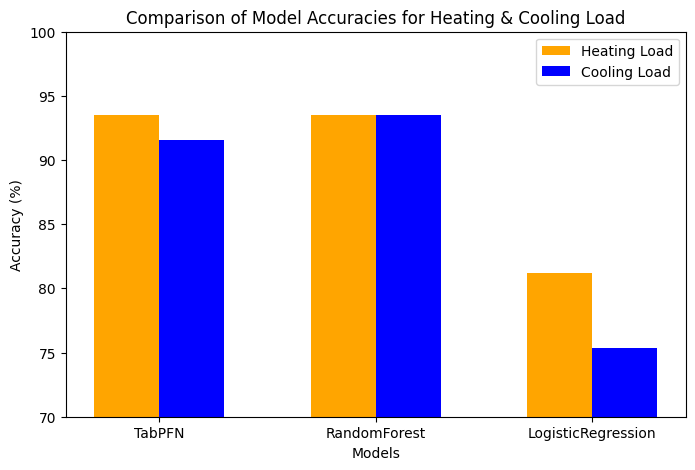

In [26]:
import matplotlib.pyplot as plt

model=['TabPFN','RandomForest','LogisticRegression']

heating_accuracy=[accuracy_heat*100,rf_accuracy_heat*100,lr_accuracy_heat*100]
cooling_accuracy=[accuracy_cool*100,rf_accuracy_cool*100,lr_accuracy_cool*100]

bar_width=0.3
x=np.arange(len(model))

plt.figure(figsize=(8,5))

plt.bar(x-bar_width/2,heating_accuracy,width=bar_width,label='Heating Load',color='orange')
plt.bar(x+bar_width/2,cooling_accuracy,width=bar_width,label='Cooling Load',color='blue')

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Model Accuracies for Heating & Cooling Load")
plt.xticks(x, model)
plt.ylim(70,100)
plt.legend()

plt.show()

# 10. Conclusion  

## **Overview of Model Performance**  

The Energy Efficiency dataset from UCI was evaluated using **TabPFN, Random Forest, and Logistic Regression** for both heating and cooling classification. Below is a summary of the accuracy results:  

### **Accuracy Comparison**  

| Model               | Heating Accuracy (%) | Cooling Accuracy (%) |  
|----------------------|---------------------|---------------------|  
| **TabPFN**          | 93.5063             | 91.5584             |  
| **Random Forest**   | 93.5065             | 93.5065             |  
| **Logistic Regression** | 81.168         | 75.3246             |  



## **Analysis of Results**  

1. **Random Forest & TabPFN Performed Similarly**  
   - For **heating classification**, **TabPFN (93.5063%)** and **Random Forest (93.5065%)** showed nearly identical accuracy.  
   - For **cooling classification**, **Random Forest (93.5065%) slightly outperformed TabPFN (91.5584%)**.  
   - This suggests that **both models were able to capture patterns in the dataset effectively** and that TabPFN did not provide a significant improvement over a traditional tree-based approach.  

2. **Logistic Regression Underperformed**  
   - Logistic Regression had the lowest accuracy (**81.168% for heating and 75.3246% for cooling**), indicating that the dataset is **not linearly separable** and requires more complex models.  
   - This further validates that tree-based methods or neural networks are more suitable for this classification problem.  





## **Final Thoughts & Next Steps**  

- **Random Forest remains a strong baseline** for this dataset, achieving the best accuracy for cooling classification and matching TabPFN in heating classification.  
- **TabPFN is still valuable for quick training and inference** but did not offer a breakthrough in accuracy.  

